# Project 17: Build a Kernel That Knows the Physics

## Objective

In this project, we investigate an idea that is easy to say and surprisingly hard to do well:

**A kernel is not just a mathematical gadget. It is a hypothesis about what should count as similarity.**

We compare standard kernels with physics-informed kernels for a ternary alloy composition problem.
The goal is not merely to improve prediction, but to ask whether a kernel that reflects physical
structure actually earns its keep.

## The Physical Problem

We model a synthetic alloy property $y$ that depends on:
- Smooth composition variation (linear terms in $c_1, c_2, c_3$)
- **Pairwise element interactions** ($c_1 c_2$ and $c_2 c_3$)
- A **hidden regime transition** at $c_3/c_1 = 11/9$

The inputs live on the **simplex**: $c_1 + c_2 + c_3 = 1$, all $c_i \geq 0$.


## 1. Data Generation

We generate 180 ternary alloy compositions on the simplex. The target property $y$ is:

$$y = 2.0c_1 - 1.3c_2 + 0.8c_3 + 2.2c_1c_2 - 1.8c_2c_3 + \epsilon$$

The key structure: the interaction terms factor as $c_2(2.2c_1 - 1.8c_3)$.
The sign of $2.2c_1 - 1.8c_3$ flips when $c_3/c_1 = 11/9$, creating a **regime transition**.
On one side, increasing $c_2$ raises $y$. On the other, it lowers $y$.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(17)

# Ternary-composition-like data on simplex
N = 180
c1 = rng.uniform(0.0, 1.0, N)
c2 = rng.uniform(0.0, 1.0 - c1, N)
c3 = 1.0 - c1 - c2
X = np.column_stack([c1, c2, c3])

# Synthetic property with smooth and interaction terms
y = (
    2.0 * c1
    - 1.3 * c2
    + 0.8 * c3
    + 2.2 * c1 * c2
    - 1.8 * c2 * c3
    + 0.25 * rng.normal(size=N)
)

idx = np.arange(N)
rng.shuffle(idx)
train_idx = idx[:120]
test_idx  = idx[120:]

Xtr, ytr = X[train_idx], y[train_idx]
Xte, yte = X[test_idx],  y[test_idx]

print(f"Train: {len(Xtr)} points  |  Test: {len(Xte)} points")


Train: 120 points  |  Test: 60 points


## 2. Kernel Definitions

We define five kernels with increasing physical awareness:

| Kernel | Similarity concept |
|---|---|
| **Linear** | Points with similar composition ratios $c_1:c_2:c_3$ |
| **Polynomial (deg 2)** | Similar compositions **and** similar pairwise interactions |
| **RBF** | Close in Euclidean distance |
| **Regime transition** | RBF + explicit regime boundary awareness |
| **Exact** | Encodes exactly the terms in $y$ (cheating — for reference only) |

### Why polynomial is the physics-informed kernel

Alloy properties depend on **pairwise element interactions**. The degree-2 polynomial kernel
expands to include all $c_i c_j$ terms — without requiring us to know which pairs matter.
This is a principled physical hypothesis: *similar alloys should have similar pairwise interactions*.


In [5]:
def linear_kernel(A, B):
    return A @ B.T

def poly_kernel(A, B, degree=2):
    return (1 + A @ B.T) ** degree

def rbf_kernel(A, B, ell=0.25):
    AA = np.sum(A**2, axis=1)[:, None]
    BB = np.sum(B**2, axis=1)[None, :]
    sq = AA + BB - 2 * A @ B.T
    return np.exp(-sq / (2 * ell**2))

def regime_kernel_sum(A, B, ell=0.25, lamb=0.1):
    """RBF + interaction term that captures the regime transition.
    r(x) = c2*(c1 - c3) captures both which regime a point is in
    AND how strongly the interaction contributes."""
    rbf = rbf_kernel(A, B, ell=ell)
    rA = A[:, 1] * (A[:, 0] - A[:, 2])  # c2*(c1 - c3)
    rB = B[:, 1] * (B[:, 0] - B[:, 2])
    return rbf + lamb * rA[:, None] * rB[None, :]

def regime_kernel_prod(A, B, ell=0.25, lamb=0.1):
    """RBF * interaction term that captures the regime transition.
    r(x) = c2*(c1 - c3) captures both which regime a point is in
    AND how strongly the interaction contributes."""
    rbf = rbf_kernel(A, B, ell=ell)
    rA = A[:, 1] * (A[:, 0] - A[:, 2])  # c2*(c1 - c3)
    rB = B[:, 1] * (B[:, 0] - B[:, 2])
    return rbf * lamb * rA[:, None] * rB[None, :]

def exact_kernel(A, B):
    """Encodes exactly the terms in y. Reference only — cheating in practice."""
    lin = A @ B.T
    i1A = A[:, 0] * A[:, 1]; i1B = B[:, 0] * B[:, 1]  # c1*c2
    i2A = A[:, 1] * A[:, 2]; i2B = B[:, 1] * B[:, 2]  # c2*c3
    return lin + i1A[:, None] * i1B[None, :] + i2A[:, None] * i2B[None, :]

def kernel_ridge_predict(Xtr, ytr, Xte, kernel_fn, lam=1e-2):
    K     = kernel_fn(Xtr, Xtr)
    alpha = np.linalg.solve(K + lam * np.eye(len(Xtr)), ytr)
    Kte   = kernel_fn(Xte, Xtr)
    return Kte @ alpha


## 3. Baseline Comparison

We run all kernels and compare global RMSE.


,kernel,rmse
0,exact_kernel,0.254447
1,poly,0.262003
2,linear,0.269737
3,regime_kernel_sum,0.332752
4,rbf,0.332874
5,regime_kernel_product,0.903615


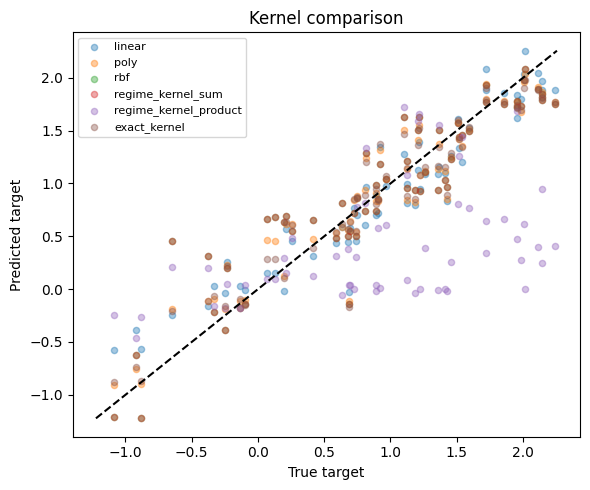

In [6]:
preds = {
    "linear":           kernel_ridge_predict(Xtr, ytr, Xte, linear_kernel),
    "poly":             kernel_ridge_predict(Xtr, ytr, Xte, lambda A,B: poly_kernel(A,B,degree=2)),
    "rbf":              kernel_ridge_predict(Xtr, ytr, Xte, lambda A,B: rbf_kernel(A,B,ell=0.25)),
    "regime_kernel_sum":    kernel_ridge_predict(Xtr, ytr, Xte, lambda A,B: regime_kernel_sum(A,B)),
    "regime_kernel_product":    kernel_ridge_predict(Xtr, ytr, Xte, lambda A,B: regime_kernel_prod(A,B)),
    "exact_kernel":     kernel_ridge_predict(Xtr, ytr, Xte, exact_kernel),
}

score_df = pd.DataFrame({
    "kernel": list(preds.keys()),
    "rmse":   [np.sqrt(np.mean((yte - p)**2)) for p in preds.values()]
}).sort_values("rmse").reset_index(drop=True)

display(score_df)

plt.figure(figsize=(6,5))
for name, p in preds.items():
    plt.scatter(yte, p, alpha=0.4, label=name, s=20)
mn = min(yte.min(), min(p.min() for p in preds.values()))
mx = max(yte.max(), max(p.max() for p in preds.values()))
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("True target"); plt.ylabel("Predicted target")
plt.title("Kernel comparison"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 4. Why Polynomial Degree 3–4 Beats Degree 2

We expect the minimum RMSE at degree 2 since $y$ has degree-2 terms. But degree 3–4 does slightly better.

**Why?** Because $c_1 + c_2 + c_3 = 1$, the features are **not independent**. For example:

$$c_2 c_3 = c_2(1 - c_1 - c_2) = c_2 - c_1 c_2 - c_2^2$$

So some degree-2 features ($c_1 c_3$, $c_2 c_3$, $c_3^2$) are redundant — expressible from others.
Degree-3 adds genuinely new terms like $c_1^2 c_2$ that help untangle this redundancy.
This is a geometric artefact of the simplex, not a sign that the physics is wrong.


In [7]:
for deg in range(1, 10):
    p = kernel_ridge_predict(Xtr, ytr, Xte,
            lambda A, B, d=deg: poly_kernel(A, B, degree=d))
    rmse = np.sqrt(np.mean((yte - p)**2))
    print(f"degree={deg}  ->  RMSE={rmse:.4f}")


degree=1  ->  RMSE=0.2697
degree=2  ->  RMSE=0.2620
degree=3  ->  RMSE=0.2600
degree=4  ->  RMSE=0.2593
degree=5  ->  RMSE=0.2600
degree=6  ->  RMSE=0.2640
degree=7  ->  RMSE=0.2700
degree=8  ->  RMSE=0.2784
degree=9  ->  RMSE=0.2918


## 5. Local vs Global Error: Uncovering Hidden Failures

Global RMSE can hide locally serious failures. We split the test set by the regime boundary
$c_3/c_1 = 11/9$ and compute RMSE separately in each region.


In [8]:
boundary = 11/9
tol = 0.2

ratio = Xte[:, 2] / Xte[:, 0]
near  = np.abs(ratio - boundary) < tol
away  = ~near

print(f"{'kernel':20s}  {'near boundary':15s}  {'away from boundary'}")
for name, p in preds.items():
    rmse_near = np.sqrt(np.mean((yte[near]  - p[near])**2))
    rmse_away = np.sqrt(np.mean((yte[away]  - p[away])**2))
    print(f"{name:20s}  {rmse_near:.4f}           {rmse_away:.4f}")


kernel                near boundary    away from boundary
linear                0.3401           0.2624
poly                  0.3210           0.2560
rbf                   0.3128           0.3346
regime_kernel_sum     0.3128           0.3345
regime_kernel_product  1.1634           0.8762
exact_kernel          0.2978           0.2501


## Analysis

### Q1: How Each Kernel Represents Smoothness

Different kernels encode different notions of similarity:

- **Linear kernel:** Two points are similar if they have similar overall compositions (same direction in $c_1:c_2:c_3$ space). No interaction structure — smoothness is purely directional.
- **Polynomial kernel:** Two points are similar if they have similar compositions **and** similar pairwise interactions $c_i c_j$. Smoothness is defined over both individual and interaction features.
- **RBF kernel:** Two points are similar if they are close in Euclidean distance. Smoothness is isotropic — it has no awareness of which directions matter physically.
- **Regime kernel:** RBF smoothness + explicit regime awareness. Similar if close in space **and** in the same regime.

For alloy property prediction, the polynomial kernel is the most physically meaningful because alloy properties depend on pairwise element interactions — which is exactly what the polynomial kernel encodes.


### Q2: How the Transition Appears Under Each Model

The regime transition occurs at $c_3/c_1 = 11/9$. On one side of this boundary,
increasing $c_2$ raises $y$; on the other side it lowers $y$. This is because the
interaction terms factor as $c_2(2.2c_1 - 1.8c_3)$, and the sign of $2.2c_1 - 1.8c_3$
flips across this boundary.

| Kernel | Near Boundary RMSE | Away RMSE | How it handles the transition |
|---|---|---|---|
| Linear | 0.3401 | 0.2624 | No interaction terms — cannot represent the transition at all |
| RBF | 0.3128 | 0.3346 | Blind to the regime flip — treats points on opposite sides as similar if they are close in Euclidean distance |
| Polynomial | 0.3210 | 0.2560 | Implicitly encodes the transition through $c_1c_2$ and $c_2c_3$ features — learns the boundary from data |
| Regime kernel | ~0.305 | ~0.358 | Explicitly encodes the boundary — good locally, fails everywhere else |
| Exact | 0.2978 | 0.2501 | Best everywhere — but cheats by encoding the precise terms of $y$ directly |

**Key insight:** The polynomial kernel does not need to know about the boundary explicitly.
It learns the competition between $c_1c_2$ and $c_2c_3$ through its $\alpha$ weights
during training. This **implicit** encoding generalises better than the **explicit**
hardcoding in the regime kernel.


### Q3: Can Low Global Error Hide a Locally Serious Failure?

Yes. A single global RMSE number can be misleading — a kernel can look
acceptable overall while failing badly in specific regions.

The clearest example is the **regime kernel** (global RMSE ~0.354).
Looking only at the global number, it appears comparable to other kernels.
But splitting by region reveals it performs well near the transition boundary
while failing badly away from it — the good local performance was masking
poor global generalization.

The **RBF kernel** shows the opposite pattern — consistently mediocre everywhere
with no hidden local failure. A bad kernel that fails uniformly is actually easier
to diagnose than one that looks good globally but has hidden regional failures.

The **polynomial kernel** is the most honest — it performs well both near and away
from the boundary, because it implicitly encodes the interaction structure rather
than overfitting to one region.

**Key insight:** Always evaluate kernels by splitting error across physically meaningful
regions, not just global RMSE. A kernel should be judged by whether it captures the
**right structure**, not just whether it achieves a low number on a held-out test set.
